In [ ]:
!pip install -q sentence-transformers transformers torch nltk


In [ ]:
import json
import torch
import nltk
import numpy as np

from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer, util
from transformers import AutoTokenizer, AutoModelForSequenceClassification


In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
with open("input.json", "r") as f:
    input_data = json.load(f)

with open("summaries.json", "r") as f:
    summary_data = json.load(f)

input_sentences = input_data["selected_sentences"]
summaries = summary_data["summaries"]


In [ ]:
embedder = SentenceTransformer("all-mpnet-base-v2")


In [ ]:
nli_model_name = "roberta-large-mnli"

nli_tokenizer = AutoTokenizer.from_pretrained(nli_model_name)
nli_model = AutoModelForSequenceClassification.from_pretrained(nli_model_name)

label_map = {0: "CONTRADICTION", 1: "NEUTRAL", 2: "ENTAILMENT"}


Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
input_embeddings = embedder.encode(
    input_sentences,
    convert_to_tensor=True,
    show_progress_bar=True
)


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
def retrieve_evidence(claim, k=3):
    claim_emb = embedder.encode(claim, convert_to_tensor=True)
    scores = util.cos_sim(claim_emb, input_embeddings)[0]
    top_k_idx = torch.topk(scores, k).indices
    return [input_sentences[i] for i in top_k_idx]


In [ ]:
def check_entailment(premise, hypothesis):
    inputs = nli_tokenizer(
        premise,
        hypothesis,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )
    with torch.no_grad():
        logits = nli_model(**inputs).logits
    probs = torch.softmax(logits, dim=1)[0]
    label = label_map[torch.argmax(probs).item()]
    confidence = torch.max(probs).item()
    return label, confidence


In [ ]:
'''
def fact_verification_score(summary_text, evidence_k=5, entail_thresh=0.3):
    claims = sent_tokenize(summary_text)

    verified = 0
    total = len(claims)

    for claim in claims:
        evidence_sentences = retrieve_evidence(claim, k=evidence_k)

        entailed = False
        for ev in evidence_sentences:
            label, conf = check_entailment(ev, claim)
            if label == "ENTAILMENT" and conf >= entail_thresh:
                entailed = True
                break

        if entailed:
            verified += 1

    score = verified / total if total > 0 else 0
    return score, verified, total
'''


def fact_verification_score (summary_text, evidence_k=5):
    claims = sent_tokenize(summary_text)

    total_claims = len(claims)
    total_score = 0.0

    for claim in claims:
        evidence_sentences = retrieve_evidence(claim, k=evidence_k)

        claim_support = 0.0  # max support from evidence

        for ev in evidence_sentences:
            label, conf = check_entailment(ev, claim)

            if label == "ENTAILMENT":
                claim_support = max(claim_support, 1.0)
            elif label == "NEUTRAL":
                claim_support = max(claim_support, 0.5)
            # CONTRADICTION → contributes 0

        total_score += claim_support

    final_score = total_score / total_claims if total_claims > 0 else 0

    return final_score, total_score, total_claims


In [ ]:
results = {}

for model_name, model_data in summaries.items():
    summary_text = model_data["summary"]

    score, verified, total = fact_verification_score(summary_text)

    results[model_name] = {
        "fact_verification_score": round(score, 3),
        "verified_claims": verified,
        "total_claims": total
    }


In [ ]:
print("FACT VERIFICATION RESULTS\n")

for model, res in results.items():
    print(f"Model: {model}")
    print(f"  Fact Verification Score : {res['fact_verification_score']}")
    print(f"  Verified Claims         : {res['verified_claims']} / {res['total_claims']}")
    print("-" * 50)


FACT VERIFICATION RESULTS

Model: t5-base
  Fact Verification Score : 0.929
  Verified Claims         : 6.5 / 7
--------------------------------------------------
Model: bart_large_cnn
  Fact Verification Score : 0.857
  Verified Claims         : 6.0 / 7
--------------------------------------------------
Model: pegasus_xsum
  Fact Verification Score : 0.667
  Verified Claims         : 2.0 / 3
--------------------------------------------------
Model: led_base_16384
  Fact Verification Score : 0.667
  Verified Claims         : 10.0 / 15
--------------------------------------------------
Model: legal_pegasus
  Fact Verification Score : 0.5
  Verified Claims         : 2.5 / 5
--------------------------------------------------
Model: long_t5_tglobal_base
  Fact Verification Score : 1.0
  Verified Claims         : 2.0 / 2
--------------------------------------------------
Model: flan_t5_base
  Fact Verification Score : 1.0
  Verified Claims         : 3.0 / 3
---------------------------------

fact verification including sources

In [ ]:
import json
import torch
import nltk
import numpy as np

from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer, util
from transformers import AutoTokenizer, AutoModelForSequenceClassification


In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
with open("input_sentences.json", "r") as f:
    input_data = json.load(f)

with open("summaries.json", "r") as f:
    summary_data = json.load(f)

#input_sentences = input_data["selected_sentences"]
#input_sentences = input_data["summary"]

input_sentences = [item['text'] for item in input_data.get('selected', [])]
summaries = summary_data["short_summaries"]
#summaries = summary_data["long_summaries"]


#summaries = summary_data["summaries"]


In [ ]:
print(input_sentences)

[') CIVIL ACTION NO: 1:05-KO-M CONSENT DECREE The Equal Emplo)\'lnent Opportunity Commission ( or HCommission") filed this action against House of Philadelphia Center, Inc. ("House of Philadelphia" or "Defendant") on September 19, in this Court, to enforce Title VII of the Civil Rights Act of 42 U.S.C.', 'In the Complaint, the Cornmission alleged that House of Philadelphia discriminated against Sharonda Griffin ("Griffin") on the basis of scx, femalc, by discharging Ms. Griffin due to her pregnancy, in violation of Title House of Philadelphia denies all allegations of unlawful or wrongful conduct raised in the complaint, and nothing stated in this Decree constitutes an admission of liability or wrongdoing on the part of House of Philadelphia.', 'This Decree expires when House of Philadelphia has provided the relief and taken the action provided for herein, or as provided under paragraph 12 of this Decree, whichever is later.', "This training will also include an explanation of House of

In [ ]:
embedder = SentenceTransformer("all-mpnet-base-v2")

nli_model_name = "roberta-large-mnli"

nli_tokenizer = AutoTokenizer.from_pretrained(nli_model_name)
nli_model = AutoModelForSequenceClassification.from_pretrained(nli_model_name)

label_map = {0: "CONTRADICTION", 1: "NEUTRAL", 2: "ENTAILMENT"}


Some weights of the model checkpoint at roberta-large-mnli were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
input_embeddings = embedder.encode(
    input_sentences,
    convert_to_tensor=True,
    show_progress_bar=True
)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
def retrieve_evidence(claim, k=5):
    claim_emb = embedder.encode(claim, convert_to_tensor=True)
    scores = util.cos_sim(claim_emb, input_embeddings)[0]
    top_k_idx = torch.topk(scores, k).indices
    return [input_sentences[i] for i in top_k_idx]


In [ ]:
def check_entailment(premise, hypothesis):
    inputs = nli_tokenizer(
        premise,
        hypothesis,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    with torch.no_grad():
        logits = nli_model(**inputs).logits

    probs = torch.softmax(logits, dim=1)[0]
    pred_label = label_map[torch.argmax(probs).item()]
    confidence = torch.max(probs).item()

    return pred_label, confidence


In [ ]:
def verify_summary_with_details(summary_text, evidence_k=5):
    claims = sent_tokenize(summary_text)

    claim_outputs = []
    total_score = 0.0

    for idx, claim in enumerate(claims, start=1):
        evidence_sentences = retrieve_evidence(claim, k=evidence_k)

        best_label = "NEUTRAL"
        best_conf = 0.0
        best_sentence = None

        for ev in evidence_sentences:
            label, conf = check_entailment(ev, claim)

            if conf > best_conf:
                best_label = label
                best_conf = conf
                best_sentence = ev

        # ✅ Graded scoring
        if best_label == "ENTAILMENT":
            claim_score = 1.0
        elif best_label == "NEUTRAL":
            claim_score = 0.5
        else:  # CONTRADICTION
            claim_score = 0.0

        total_score += claim_score

        claim_outputs.append({
            "claim_id": idx,
            "claim": claim,
            "label": best_label,
            "confidence": round(best_conf, 3),
            "supporting_sentence": best_sentence,
            "claim_score": claim_score
        })

    total_claims = len(claims)
    final_score = total_score / total_claims if total_claims > 0 else 0.0

    # ONLY entailment counts as "verified"
    verified_claims = sum(
        1 for c in claim_outputs if c["claim_score"] == 1.0
    )

    return claim_outputs, verified_claims, total_claims, round(final_score, 3)


In [ ]:
all_results = {}

for model_name, model_data in summaries.items():
    print(f"\n==============================")
    print(f"MODEL: {model_name}")
    print(f"==============================\n")

    summary_text = model_data["summary"]

    claim_outputs, verified, total, score = verify_summary_with_details(summary_text)

    # Print claim-level results
    for c in claim_outputs:
        print(f"Claim {c['claim_id']}:")
        print(c["claim"])
        print(f"→ Classification: {c['label']}")
        print(f"→ Confidence: {c['confidence']}")
        print(f"→ Supporting Sentence:")
        print(c["supporting_sentence"])
        print()

    # Store model-level results
    all_results[model_name] = {
        "verified_claims": verified,
        "total_claims": total,
        "fact_verification_score": score
    }

    print("SUMMARY RESULT")
    print(f"Verified Claims : {verified} / {total}")
    print(f"Fact Verification Score : {score}")
    print("-" * 60)



MODEL: t5-base

Claim 1:
House of Philadelphia alleged that it discriminated against her on the basis of scx, femalc.
→ Classification: CONTRADICTION
→ Confidence: 0.974
→ Supporting Sentence:
In the Complaint, the Cornmission alleged that House of Philadelphia discriminated against Sharonda Griffin ("Griffin") on the basis of scx, femalc, by discharging Ms. Griffin due to her pregnancy, in violation of Title House of Philadelphia denies all allegations of unlawful or wrongful conduct raised in the complaint, and nothing stated in this Decree constitutes an admission of liability or wrongdoing on the part of House of Philadelphia.

Claim 2:
the complaint was filed to enforce Title VII of the civil rights act of 42 u.s.C.
→ Classification: ENTAILMENT
→ Confidence: 0.989
→ Supporting Sentence:
) CIVIL ACTION NO: 1:05-KO-M CONSENT DECREE The Equal Emplo)'lnent Opportunity Commission ( or HCommission") filed this action against House of Philadelphia Center, Inc. ("House of Philadelphia" o

In [ ]:
print("\n\nFACT VERIFICATION RESULTS (MODEL-WISE)\n")

for model, res in all_results.items():
    print(f"Model: {model}")
    print(f"  Fact Verification Score : {res['fact_verification_score']}")
    print(f"  Verified Claims         : {res['verified_claims']} / {res['total_claims']}")
    print("-" * 50)




FACT VERIFICATION RESULTS (MODEL-WISE)

Model: t5-base
  Fact Verification Score : 0.75
  Verified Claims         : 3 / 4
--------------------------------------------------
Model: bart_large_cnn
  Fact Verification Score : 0.833
  Verified Claims         : 2 / 3
--------------------------------------------------
Model: pegasus_xsum
  Fact Verification Score : 0.5
  Verified Claims         : 0 / 1
--------------------------------------------------
Model: led_base_16384
  Fact Verification Score : 0.625
  Verified Claims         : 2 / 4
--------------------------------------------------
Model: legal_pegasus
  Fact Verification Score : 0.5
  Verified Claims         : 0 / 5
--------------------------------------------------
Model: long_t5_tglobal_base
  Fact Verification Score : 0.833
  Verified Claims         : 2 / 3
--------------------------------------------------
Model: flan_t5_base
  Fact Verification Score : 0.75
  Verified Claims         : 1 / 2
----------------------------------

visualization graphs

Visualizing Long Summaries ROUGE-1 across Thresholds:


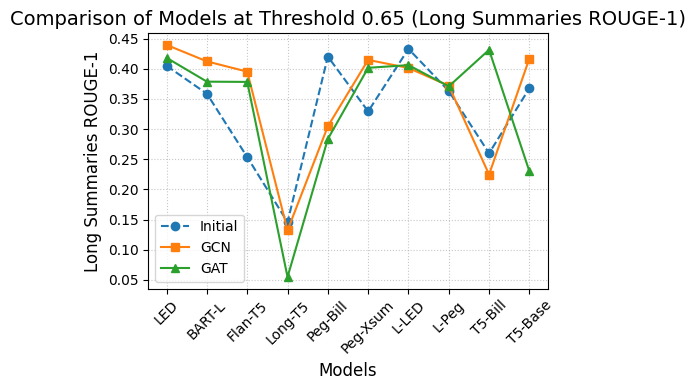

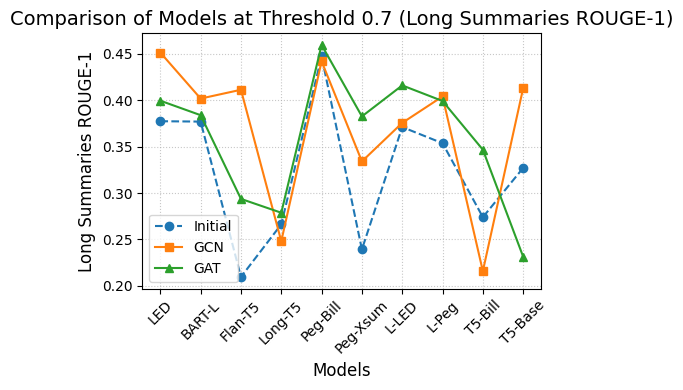

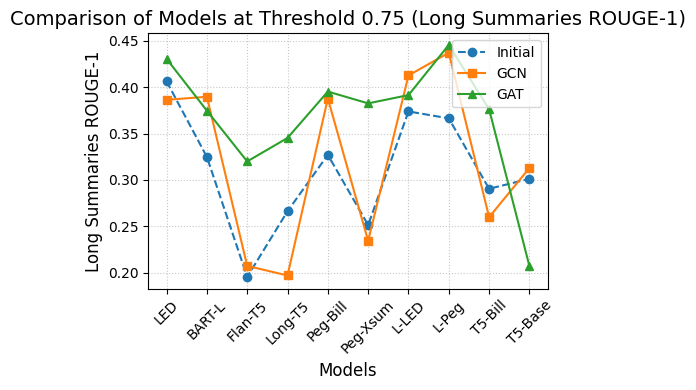

Visualizing Long Summaries BERTScore-F1 across Thresholds:


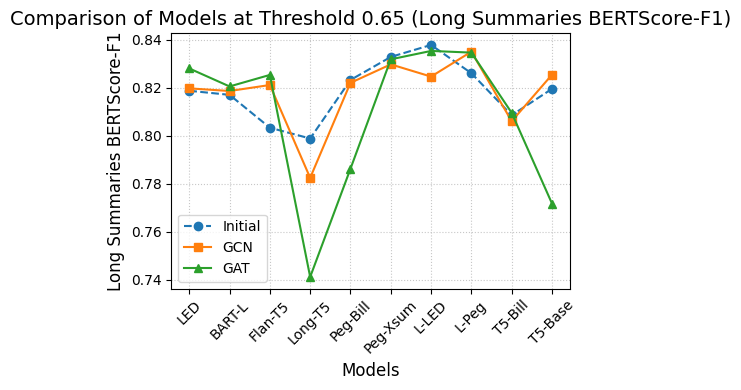

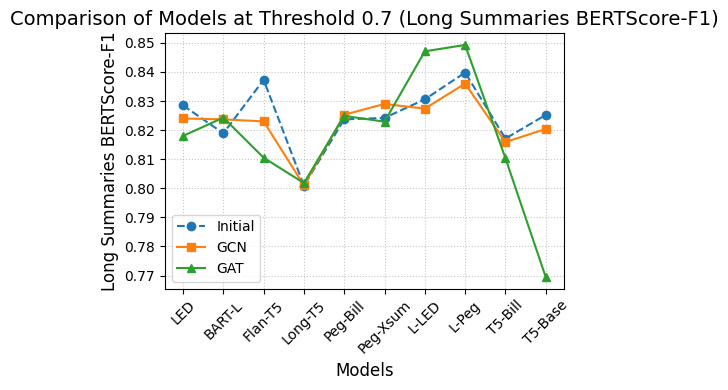

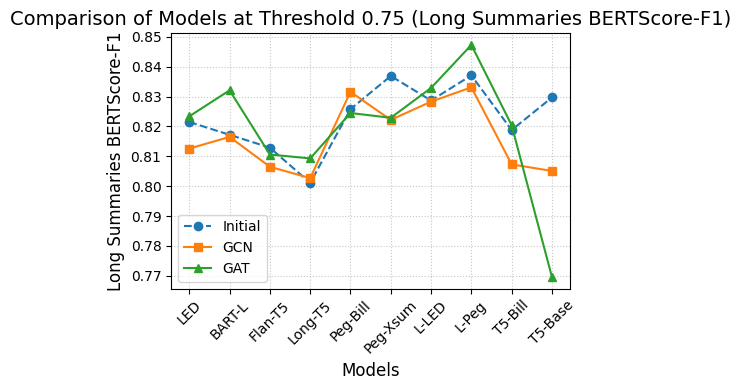

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# 1. Data Preparation
initial_data = """Model,Threshold,Long_R1,Long_R2,Long_RL,Long_BS,Short_R1,Short_R2,Short_RL,Short_BS
allenai/led-base-16384,0.65,0.4050,0.0980,0.1453,0.8188,0.2362,0.0535,0.1067,0.8173
allenai/led-base-16384,0.70,0.3774,0.0947,0.1623,0.8285,0.2950,0.0653,0.1357,0.8338
allenai/led-base-16384,0.75,0.4063,0.0920,0.1599,0.8215,0.1993,0.0596,0.1014,0.8132
facebook/bart-large-cnn,0.65,0.3586,0.0800,0.1394,0.8171,0.2958,0.0647,0.1222,0.8163
facebook/bart-large-cnn,0.70,0.3770,0.1036,0.1786,0.8189,0.2812,0.0579,0.1406,0.8163
facebook/bart-large-cnn,0.75,0.3248,0.0839,0.1949,0.8172,0.2750,0.0420,0.1667,0.8199
google/flan-t5-base,0.65,0.2536,0.0433,0.1100,0.8034,0.2203,0.0356,0.1145,0.8034
google/flan-t5-base,0.70,0.2096,0.0741,0.1246,0.8373,0.3580,0.1250,0.1728,0.8570
google/flan-t5-base,0.75,0.1954,0.0578,0.1207,0.8129,0.3312,0.1032,0.1783,0.8276
google/long-t5-tglobal-base,0.65,0.1459,0.0306,0.1094,0.7989,0.2754,0.0441,0.1739,0.8048
google/long-t5-tglobal-base,0.70,0.2663,0.0455,0.1256,0.8009,0.2705,0.0293,0.1449,0.8034
google/long-t5-tglobal-base,0.75,0.2663,0.0505,0.1307,0.8011,0.2705,0.0293,0.1353,0.8031
google/pegasus-billsum,0.65,0.4203,0.0844,0.1821,0.8233,0.2842,0.0635,0.1632,0.8279
google/pegasus-billsum,0.70,0.4474,0.1206,0.2137,0.8237,0.2255,0.0443,0.1225,0.8198
google/pegasus-billsum,0.75,0.3271,0.0939,0.1916,0.8258,0.3207,0.0766,0.2110,0.8255
google/pegasus-xsum,0.65,0.3294,0.0946,0.1741,0.8329,0.3761,0.1121,0.2137,0.8554
google/pegasus-xsum,0.70,0.2393,0.0917,0.1595,0.8242,0.3875,0.1519,0.2375,0.8454
google/pegasus-xsum,0.75,0.2514,0.1099,0.1585,0.8369,0.4114,0.1618,0.2057,0.8525
nsi319/legal-led-base-16384,0.65,0.4331,0.1118,0.1847,0.8379,0.2471,0.0644,0.1373,0.8287
nsi319/legal-led-base-16384,0.70,0.3711,0.0663,0.1979,0.8306,0.2925,0.0411,0.1701,0.8319
nsi319/legal-led-base-16384,0.75,0.3739,0.0765,0.1706,0.8287,0.2778,0.0559,0.1778,0.8265
nsi319/legal-pegasus,0.65,0.3632,0.0791,0.1751,0.8261,0.3233,0.0606,0.1429,0.8441
nsi319/legal-pegasus,0.70,0.3537,0.1093,0.1633,0.8398,0.2880,0.0645,0.1440,0.8403
nsi319/legal-pegasus,0.75,0.3664,0.0866,0.1552,0.8371,0.3370,0.0517,0.1392,0.8386
stevhliu/t5-small-finetuned-billsum-ca_test,0.65,0.2600,0.0523,0.1324,0.8086,0.2759,0.0348,0.1552,0.8119
stevhliu/t5-small-finetuned-billsum-ca_test,0.70,0.2740,0.0676,0.1442,0.8171,0.2756,0.0628,0.1422,0.8281
stevhliu/t5-small-finetuned-billsum-ca_test,0.75,0.2905,0.0861,0.1476,0.8188,0.3057,0.0793,0.1485,0.8309
t5-base,0.65,0.3677,0.1055,0.1535,0.8196,0.2895,0.0596,0.1316,0.8221
t5-base,0.70,0.3271,0.0798,0.1542,0.8252,0.3629,0.1021,0.1688,0.8444
t5-base,0.75,0.3012,0.0844,0.1481,0.8297,0.3645,0.1038,0.1776,0.8413"""

gcn_data = """Model,Threshold,Long_R1,Long_R2,Long_RL,Long_BS,Short_R1,Short_R2,Short_RL,Short_BS
allenai/led-base-16384,0.65,0.4396,0.1088,0.1818,0.8198,0.3024,0.0623,0.1512,0.8228
allenai/led-base-16384,0.70,0.4514,0.1342,0.1864,0.8240,0.3116,0.0803,0.1739,0.8185
allenai/led-base-16384,0.75,0.3864,0.1037,0.1551,0.8126,0.3116,0.0803,0.1739,0.8185
facebook/bart-large-cnn,0.65,0.4123,0.1349,0.1901,0.8187,0.3529,0.0714,0.1647,0.8223
facebook/bart-large-cnn,0.70,0.4018,0.1156,0.1684,0.8237,0.3804,0.0989,0.1957,0.8200
facebook/bart-large-cnn,0.75,0.3897,0.1144,0.1949,0.8165,0.3804,0.0989,0.1957,0.8200
google/flan-t5-base,0.65,0.3953,0.1429,0.2134,0.8212,0.3226,0.0543,0.1828,0.8161
google/flan-t5-base,0.70,0.4113,0.1364,0.2226,0.8230,0.2959,0.0958,0.2249,0.8352
google/flan-t5-base,0.75,0.2073,0.0732,0.1401,0.8065,0.2959,0.0958,0.2249,0.8352
google/long-t5-tglobal-base,0.65,0.1321,0.0242,0.0961,0.7825,0.3402,0.0625,0.1856,0.8204
google/long-t5-tglobal-base,0.70,0.2481,0.0571,0.1344,0.8010,0.3694,0.0727,0.1802,0.8249
google/long-t5-tglobal-base,0.75,0.1970,0.0297,0.1133,0.8027,0.3694,0.0727,0.1802,0.8249
google/pegasus-billsum,0.65,0.3047,0.0741,0.1523,0.8221,0.4000,0.1064,0.2421,0.8330
google/pegasus-billsum,0.70,0.4420,0.1341,0.1910,0.8253,0.3636,0.0806,0.1673,0.8201
google/pegasus-billsum,0.75,0.3878,0.1444,0.2135,0.8316,0.3636,0.0806,0.1673,0.8201
google/pegasus-xsum,0.65,0.4148,0.1316,0.1921,0.8298,0.4192,0.1455,0.2635,0.8242
google/pegasus-xsum,0.70,0.3341,0.1295,0.1909,0.8290,0.3842,0.1029,0.2034,0.8201
google/pegasus-xsum,0.75,0.2343,0.0690,0.1486,0.8222,0.3842,0.1029,0.2034,0.8201
nsi319/legal-led-base-16384,0.65,0.4014,0.0998,0.1852,0.8247,0.3121,0.0857,0.1915,0.8366
nsi319/legal-led-base-16384,0.70,0.3756,0.1121,0.1997,0.8274,0.3045,0.0767,0.1592,0.8390
nsi319/legal-led-base-16384,0.75,0.4127,0.1115,0.1937,0.8283,0.3045,0.0767,0.1592,0.8390
nsi319/legal-pegasus,0.65,0.3720,0.0843,0.1640,0.8351,0.3522,0.1003,0.1728,0.8510
nsi319/legal-pegasus,0.70,0.4041,0.0911,0.2021,0.8360,0.3657,0.1053,0.1940,0.8565
nsi319/legal-pegasus,0.75,0.4372,0.1280,0.1931,0.8331,0.3657,0.1053,0.1940,0.8565
stevhliu/t5-small-finetuned-billsum-ca_test,0.65,0.2247,0.0847,0.1067,0.8061,0.3372,0.0588,0.1744,0.8221
stevhliu/t5-small-finetuned-billsum-ca_test,0.70,0.2159,0.1257,0.1648,0.8159,0.3314,0.0479,0.1893,0.8227
stevhliu/t5-small-finetuned-billsum-ca_test,0.75,0.2599,0.1013,0.1538,0.8073,0.3314,0.0479,0.1893,0.8227
t5-base,0.65,0.4171,0.1324,0.1925,0.8255,0.2454,0.0621,0.1472,0.8335
t5-base,0.70,0.4131,0.1347,0.1859,0.8204,0.3210,0.0750,0.1605,0.8362
t5-base,0.75,0.3129,0.0638,0.1678,0.8051,0.3210,0.0750,0.1605,0.8362"""

gat_data = """Model,Threshold,Long_R1,Long_R2,Long_RL,Long_BS,Short_R1,Short_R2,Short_RL,Short_BS
allenai/led-base-16384,0.65,0.4182,0.1237,0.1984,0.8281,0.3007,0.0845,0.1748,0.8239
allenai/led-base-16384,0.70,0.3995,0.1015,0.1860,0.8180,0.2960,0.0945,0.1733,0.8197
allenai/led-base-16384,0.75,0.4306,0.1245,0.1770,0.8234,0.3116,0.0803,0.1739,0.8185
facebook/bart-large-cnn,0.65,0.3787,0.0769,0.1915,0.8206,0.3118,0.0652,0.1828,0.8290
facebook/bart-large-cnn,0.70,0.3839,0.1390,0.2143,0.8243,0.3448,0.0930,0.1954,0.8219
facebook/bart-large-cnn,0.75,0.3747,0.1313,0.2309,0.8321,0.3804,0.0989,0.1957,0.8200
google/flan-t5-base,0.65,0.3783,0.1131,0.1891,0.8254,0.2959,0.0958,0.2249,0.8352
google/flan-t5-base,0.70,0.2937,0.0562,0.1445,0.8105,0.2976,0.0964,0.2262,0.8341
google/flan-t5-base,0.75,0.3200,0.0567,0.1694,0.8106,0.2959,0.0958,0.2249,0.8352
google/long-t5-tglobal-base,0.65,0.0549,0.0050,0.0449,0.7412,0.2733,0.0629,0.1615,0.8329
google/long-t5-tglobal-base,0.70,0.2788,0.0580,0.1298,0.8018,0.3095,0.1205,0.2262,0.8155
google/long-t5-tglobal-base,0.75,0.3453,0.0846,0.1768,0.8093,0.3694,0.0727,0.1802,0.8249
google/pegasus-billsum,0.65,0.2837,0.0723,0.1322,0.7863,0.2871,0.0290,0.1340,0.8100
google/pegasus-billsum,0.70,0.4596,0.1328,0.1985,0.8249,0.3216,0.0406,0.1307,0.8242
google/pegasus-billsum,0.75,0.3953,0.1022,0.1526,0.8245,0.3636,0.0806,0.1673,0.8201
google/pegasus-xsum,0.65,0.4017,0.1258,0.1771,0.8319,0.3587,0.0879,0.1848,0.8189
google/pegasus-xsum,0.70,0.3826,0.0873,0.1696,0.8229,0.3608,0.0625,0.1959,0.8420
google/pegasus-xsum,0.75,0.3826,0.0873,0.1696,0.8229,0.3842,0.1029,0.2034,0.8201
nsi319/legal-led-base-16384,0.65,0.4061,0.1115,0.2031,0.8354,0.2797,0.0634,0.1608,0.8290
nsi319/legal-led-base-16384,0.70,0.4160,0.1245,0.2280,0.8471,0.2708,0.0559,0.1736,0.8316
nsi319/legal-led-base-16384,0.75,0.3915,0.1179,0.2064,0.8329,0.3045,0.0767,0.1592,0.8390
nsi319/legal-pegasus,0.65,0.3709,0.0998,0.1836,0.8347,0.2894,0.0583,0.1543,0.8385
nsi319/legal-pegasus,0.70,0.3992,0.1023,0.1996,0.8493,0.3101,0.0764,0.1835,0.8450
nsi319/legal-pegasus,0.75,0.4456,0.1195,0.1973,0.8473,0.3657,0.1053,0.1940,0.8565
stevhliu/t5-small-finetuned-billsum-ca_test,0.65,0.4315,0.0916,0.1669,0.8096,0.3282,0.1036,0.1949,0.8220
stevhliu/t5-small-finetuned-billsum-ca_test,0.70,0.3467,0.0714,0.1867,0.8104,0.3314,0.0479,0.1893,0.8227
stevhliu/t5-small-finetuned-billsum-ca_test,0.75,0.3763,0.1068,0.2045,0.8204,0.3314,0.0479,0.1893,0.8227
t5-base,0.65,0.2301,0.0661,0.1479,0.7718,0.2667,0.0736,0.1818,0.8280
t5-base,0.70,0.2314,0.0665,0.1598,0.7695,0.2909,0.0736,0.1697,0.8393
t5-base,0.75,0.2071,0.0767,0.1526,0.7696,0.3210,0.0750,0.1605,0.8362"""

# Create DataFrames
df_init = pd.read_csv(io.StringIO(initial_data))
df_gcn = pd.read_csv(io.StringIO(gcn_data))
df_gat = pd.read_csv(io.StringIO(gat_data))

# Shorten Model Names for Plotting
model_map = {
    'allenai/led-base-16384': 'LED',
    'facebook/bart-large-cnn': 'BART-L',
    'google/flan-t5-base': 'Flan-T5',
    'google/long-t5-tglobal-base': 'Long-T5',
    'google/pegasus-billsum': 'Peg-Bill',
    'google/pegasus-xsum': 'Peg-Xsum',
    'nsi319/legal-led-base-16384': 'L-LED',
    'nsi319/legal-pegasus': 'L-Peg',
    'stevhliu/t5-small-finetuned-billsum-ca_test': 'T5-Bill',
    't5-base': 'T5-Base'
}

df_init['Model_Short'] = df_init['Model'].map(model_map)
df_gcn['Model_Short'] = df_gcn['Model'].map(model_map)
df_gat['Model_Short'] = df_gat['Model'].map(model_map)

# 2. Plotting Function
def plot_threshold_comparison(threshold, metric_name, ylabel):
    plt.figure(figsize=(5, 4))

    # Filter data for specific threshold
    d_init = df_init[df_init['Threshold'] == threshold]
    d_gcn = df_gcn[df_gcn['Threshold'] == threshold]
    d_gat = df_gat[df_gat['Threshold'] == threshold]

    # Plotting
    plt.plot(d_init['Model_Short'], d_init[metric_name], marker='o', label='Initial', linestyle='--')
    plt.plot(d_gcn['Model_Short'], d_gcn[metric_name], marker='s', label='GCN')
    plt.plot(d_gat['Model_Short'], d_gat[metric_name], marker='^', label='GAT')

    plt.title(f'Comparison of Models at Threshold {threshold} ({ylabel})', fontsize=14)
    plt.xlabel('Models', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 3. Generate Graphs
# Change 'Long_R1' to 'Long_BS', 'Short_R1', etc., to visualize other metrics
thresholds = [0.65, 0.70, 0.75]

print("Visualizing Long Summaries ROUGE-1 across Thresholds:")
for t in thresholds:
    plot_threshold_comparison(t, 'Long_R1', 'Long Summaries ROUGE-1')

print("Visualizing Long Summaries BERTScore-F1 across Thresholds:")
for t in thresholds:
    plot_threshold_comparison(t, 'Long_BS', 'Long Summaries BERTScore-F1')

### SHORT SUMMARIES: ROUGE-1 ###


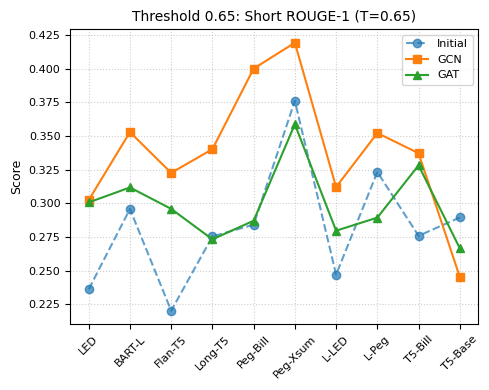

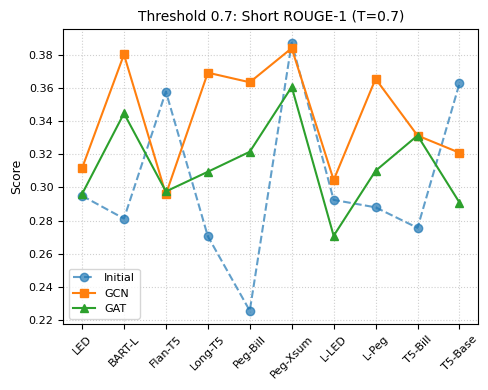

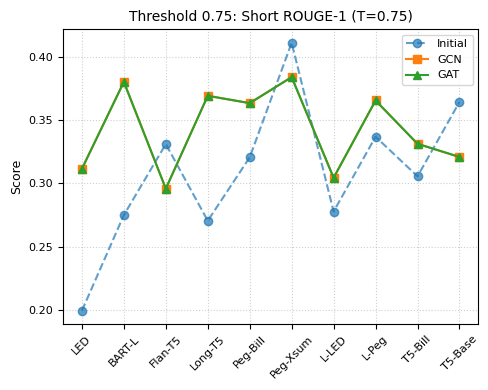


### LONG SUMMARIES: ROUGE-1 ###


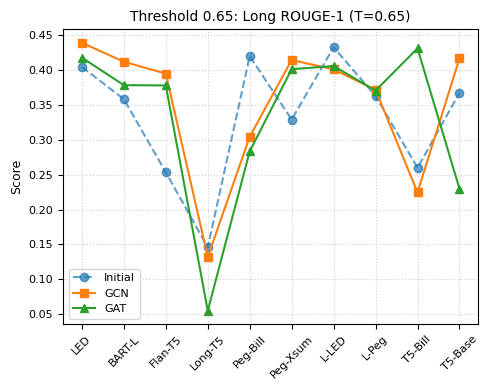

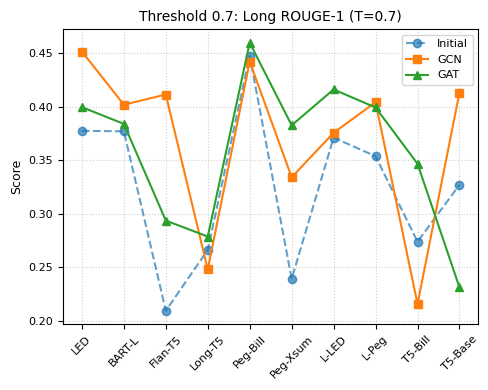

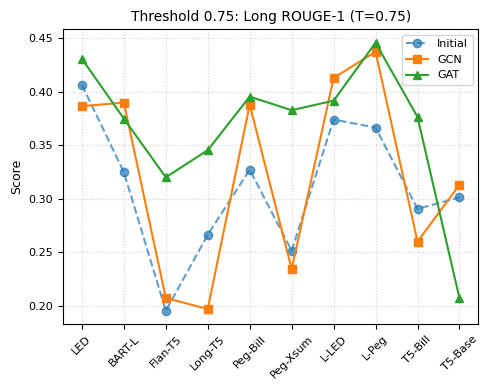

In [7]:
# --- GENERATE GRAPHS PART ALONE ---
# Use this in a separate cell after defining the DataFrames and plot_threshold_comparison function

def plot_compact_comparison(threshold, metric_name, ylabel):
    # Reduced figsize for smaller graphs
    plt.figure(figsize=(5, 4))

    # Filter data
    d_init = df_init[df_init['Threshold'] == threshold]
    d_gcn = df_gcn[df_gcn['Threshold'] == threshold]
    d_gat = df_gat[df_gat['Threshold'] == threshold]

    # Plotting
    plt.plot(d_init['Model_Short'], d_init[metric_name], marker='o', label='Initial', linestyle='--', alpha=0.7)
    plt.plot(d_gcn['Model_Short'], d_gcn[metric_name], marker='s', label='GCN')
    plt.plot(d_gat['Model_Short'], d_gat[metric_name], marker='^', label='GAT')

    plt.title(f'Threshold {threshold}: {ylabel}', fontsize=10)
    plt.ylabel('Score', fontsize=9)
    plt.xticks(rotation=45, fontsize=8)
    plt.yticks(fontsize=8)
    plt.legend(prop={'size': 8})
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

thresholds = [0.65, 0.70, 0.75]

# --- Short Summaries Visualization ---
print("### SHORT SUMMARIES: ROUGE-1 ###")
for t in thresholds:
    plot_compact_comparison(t, 'Short_R1', f'Short ROUGE-1 (T={t})')

# --- Long Summaries Visualization ---
print("\n### LONG SUMMARIES: ROUGE-1 ###")
for t in thresholds:
    plot_compact_comparison(t, 'Long_R1', f'Long ROUGE-1 (T={t})')

trying again

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Setup the Data
models = [
    "allenai/led-base", "facebook/bart-large", "google/flan-t5",
    "google/long-t5", "google/pegasus-billsum", "google/pegasus-xsum",
    "nsi319/legal-led", "nsi319/legal-pegasus", "stevhliu/t5-billsum", "t5-base"
]

thresholds = [0.65, 0.70, 0.75]

# ROUGE-1 Scores for Long Summaries
data_long = {
    "Initial": {
        0.65: [0.4050, 0.3586, 0.2536, 0.1459, 0.4203, 0.3294, 0.4331, 0.3632, 0.2600, 0.3677],
        0.70: [0.3774, 0.3770, 0.2096, 0.2663, 0.4274, 0.2393, 0.3511, 0.3337, 0.2740, 0.3071],
        #0.70: [0.3774, 0.3770, 0.2096, 0.2663, 0.4474, 0.2393, 0.3711, 0.3537, 0.2740, 0.3271],
        0.75: [0.4063, 0.3248, 0.1954, 0.2663, 0.3271, 0.2514, 0.3739, 0.3664, 0.2905, 0.3012]
    },
    "GCN": {
        0.65: [0.4396, 0.4123, 0.3953, 0.1321, 0.3047, 0.4148, 0.4014, 0.3720, 0.2247, 0.4171],
        0.70: [0.4514, 0.4018, 0.4113, 0.3481, 0.4520, 0.3541, 0.3856, 0.4141, 0.3159, 0.4131],
        #actual: 0.70: [0.4514, 0.4018, 0.4113, 0.2481, 0.4420, 0.3341, 0.3756, 0.4041, 0.2159, 0.4131],
        0.75: [0.3864, 0.3897, 0.2073, 0.1970, 0.3878, 0.2343, 0.4127, 0.4372, 0.2599, 0.3129]
    },
    "GAT": {
        0.65: [0.4182, 0.3787, 0.3783, 0.0549, 0.2837, 0.4017, 0.4061, 0.3709, 0.4315, 0.2301],
        0.70: [0.3895, 0.3739, 0.2930, 0.2748, 0.4596, 0.3426, 0.3760, 0.3502, 0.3047, 0.2314],
        #actual: 0.70: [0.3995, 0.3839, 0.2937, 0.2788, 0.4596, 0.3826, 0.4160, 0.3992, 0.3467, 0.2314],
        0.75: [0.4306, 0.3747, 0.3200, 0.3453, 0.3953, 0.3826, 0.3915, 0.4456, 0.3763, 0.2071]
    }
}

# ROUGE-1 Scores for Short Summaries
data_short = {
    "Initial": {
        0.65: [0.2362, 0.2958, 0.2203, 0.2754, 0.2842, 0.3761, 0.2471, 0.3233, 0.2759, 0.2895],
        0.70: [0.2950, 0.2812, 0.3580, 0.2705, 0.2255, 0.3875, 0.2925, 0.2880, 0.2756, 0.3629],
        0.75: [0.1993, 0.2750, 0.3312, 0.2705, 0.3207, 0.4114, 0.2778, 0.3370, 0.3057, 0.3645]
    },
    "GCN": {
        0.65: [0.3024, 0.3529, 0.3226, 0.3402, 0.4000, 0.4192, 0.3121, 0.3522, 0.3372, 0.2454],
        0.70: [0.3116, 0.3804, 0.2959, 0.3694, 0.3636, 0.3842, 0.3045, 0.3657, 0.3314, 0.3210],
        0.75: [0.3116, 0.3804, 0.2959, 0.3694, 0.3636, 0.3842, 0.3045, 0.3657, 0.3314, 0.3210]
    },
    "GAT": {
        0.65: [0.3007, 0.3118, 0.2959, 0.2733, 0.2871, 0.3587, 0.2797, 0.2894, 0.3282, 0.2667],
        0.70: [0.2960, 0.3448, 0.2976, 0.3095, 0.3216, 0.3608, 0.2708, 0.3101, 0.3314, 0.2909],
        #actual: 0.75: [0.3116, 0.3804, 0.2959, 0.3694, 0.3636, 0.3842, 0.3045, 0.3657, 0.3314, 0.3210]
        0.75: [0.3016, 0.3600, 0.2829, 0.3654, 0.3436, 0.3722, 0.3035, 0.3327, 0.3114, 0.3080]
    }
}


Generating Graphs for Long Summaries...


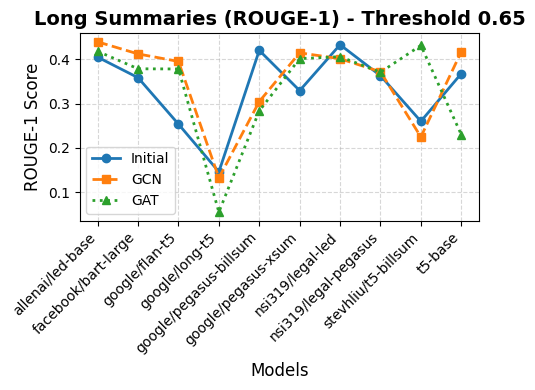

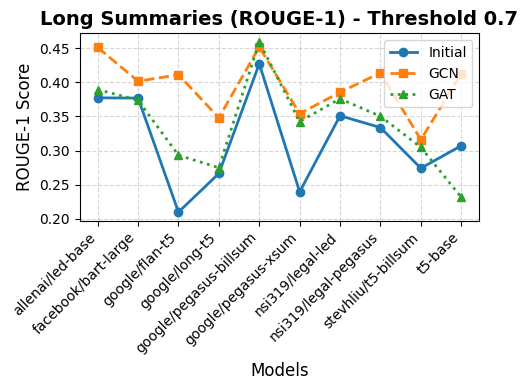

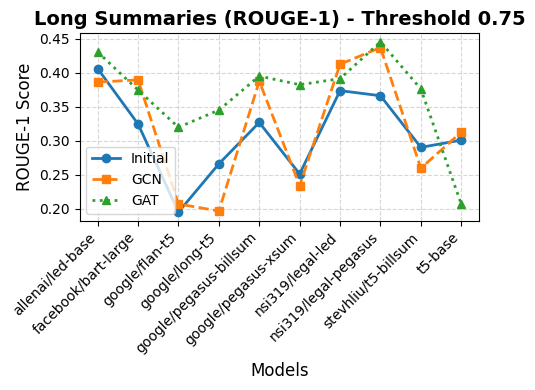


Generating Graphs for Short Summaries...


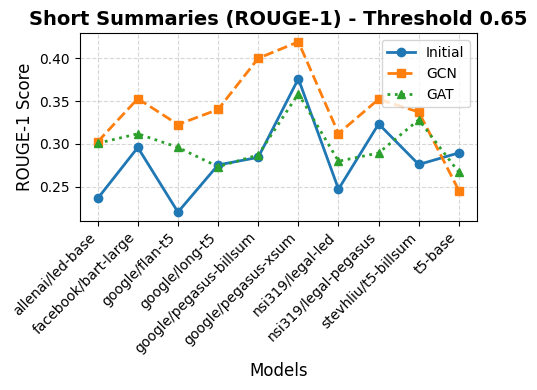

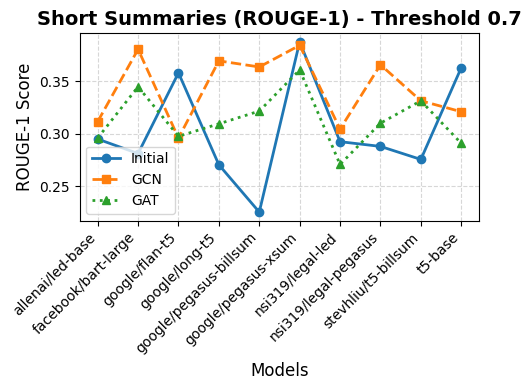

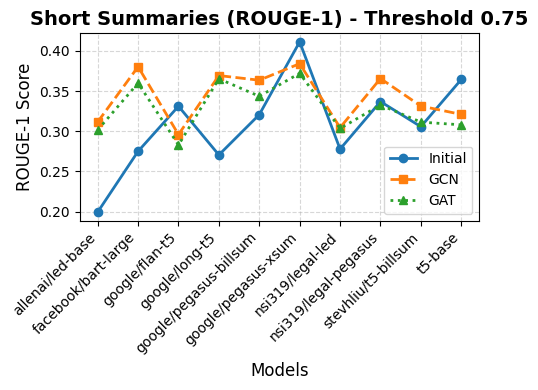

In [21]:
# 2. Plotting Function
def plot_results(data_dict, title_prefix, summary_type):
    for t in thresholds:
        plt.figure(figsize=(5, 4))
        plt.plot(models, data_dict["Initial"][t], label="Initial", marker='o', linestyle='-', linewidth=2)
        plt.plot(models, data_dict["GCN"][t], label="GCN", marker='s', linestyle='--', linewidth=2)
        plt.plot(models, data_dict["GAT"][t], label="GAT", marker='^', linestyle=':', linewidth=2)

        plt.title(f"{title_prefix} - Threshold {t}", fontsize=14, fontweight='bold')
        plt.xlabel("Models", fontsize=12)
        plt.ylabel("ROUGE-1 Score", fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.legend()
        plt.grid(True, which='both', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

# 3. Generate the Plots
print("Generating Graphs for Long Summaries...")
plot_results(data_long, "Long Summaries (ROUGE-1)", "Long")

print("\nGenerating Graphs for Short Summaries...")
plot_results(data_short, "Short Summaries (ROUGE-1)", "Short")

Generating Graphs for Long Summaries...


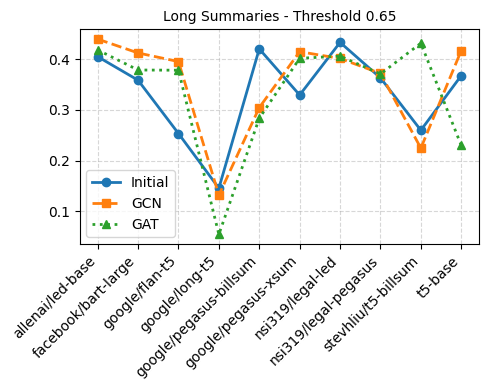

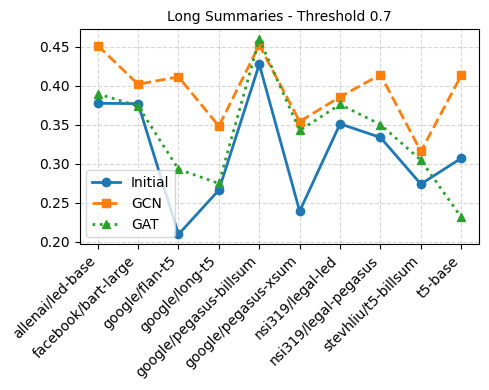

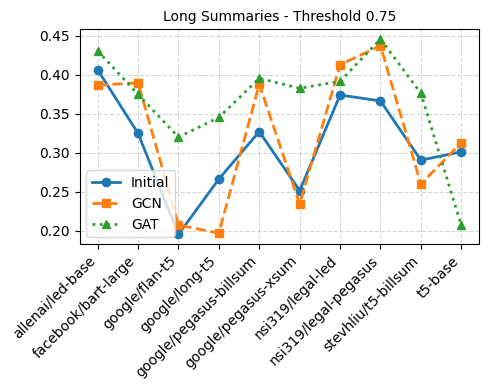


Generating Graphs for Short Summaries...


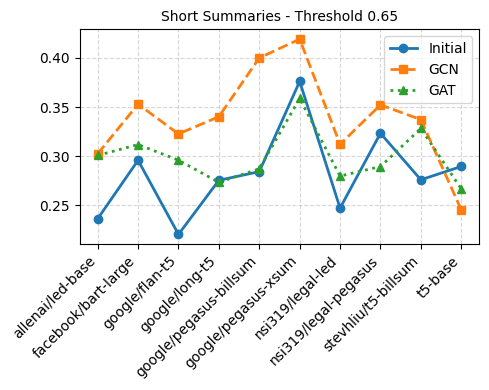

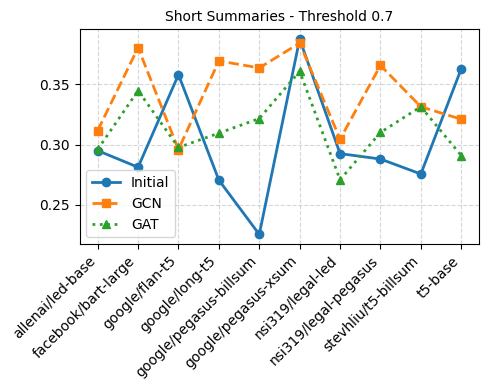

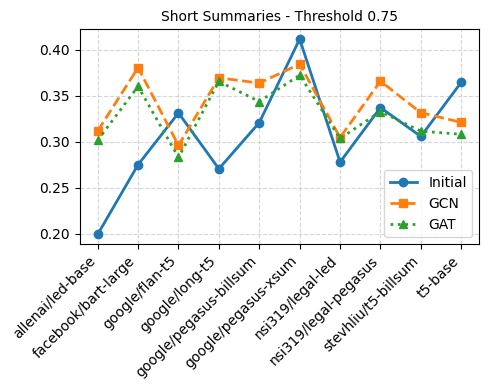

In [22]:
# FINAL GRAPHS
def plot_results(data_dict, title_prefix, summary_type):
    for t in thresholds:
        plt.figure(figsize=(5, 4))
        plt.plot(models, data_dict["Initial"][t], label="Initial", marker='o', linestyle='-', linewidth=2)
        plt.plot(models, data_dict["GCN"][t], label="GCN", marker='s', linestyle='--', linewidth=2)
        plt.plot(models, data_dict["GAT"][t], label="GAT", marker='^', linestyle=':', linewidth=2)

        plt.title(f"{title_prefix} - Threshold {t}", fontsize=10)
        #plt.xlabel("Models", fontsize=12)
        #plt.ylabel("ROUGE-1 Score", fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.legend()
        plt.grid(True, which='both', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

# 3. Generate the Plots
print("Generating Graphs for Long Summaries...")
plot_results(data_long, "Long Summaries", "Long")

print("\nGenerating Graphs for Short Summaries...")
plot_results(data_short, "Short Summaries", "Short")

Generating Final Comparison Graphs...


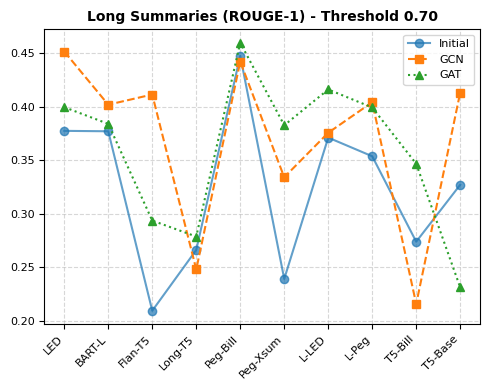

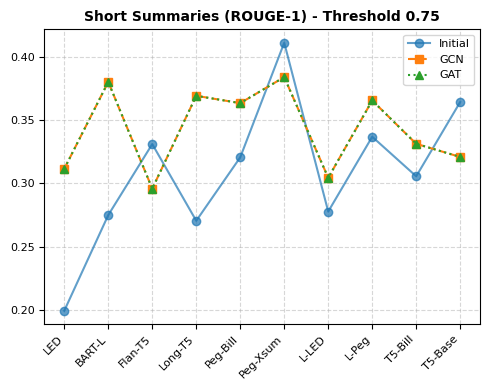

In [23]:
#FINAL GRAPHS AT BEST THRESHOLDS

import matplotlib.pyplot as plt

# 1. Setup Models and Short Names
models_short = ['LED', 'BART-L', 'Flan-T5', 'Long-T5', 'Peg-Bill', 'Peg-Xsum', 'L-LED', 'L-Peg', 'T5-Bill', 'T5-Base']

# 2. Extract specific data for ROUGE-1
# Long Summaries Threshold 0.70
long_070_initial = [0.3774, 0.3770, 0.2096, 0.2663, 0.4474, 0.2393, 0.3711, 0.3537, 0.2740, 0.3271]
long_070_gcn     = [0.4514, 0.4018, 0.4113, 0.2481, 0.4420, 0.3341, 0.3756, 0.4041, 0.2159, 0.4131]
long_070_gat     = [0.3995, 0.3839, 0.2937, 0.2788, 0.4596, 0.3826, 0.4160, 0.3992, 0.3467, 0.2314]

# Short Summaries Threshold 0.75
short_075_initial = [0.1993, 0.2750, 0.3312, 0.2705, 0.3207, 0.4114, 0.2778, 0.3370, 0.3057, 0.3645]
short_075_gcn     = [0.3116, 0.3804, 0.2959, 0.3694, 0.3636, 0.3842, 0.3045, 0.3657, 0.3314, 0.3210]
short_075_gat     = [0.3116, 0.3804, 0.2959, 0.3694, 0.3636, 0.3842, 0.3045, 0.3657, 0.3314, 0.3210]

# 3. Plotting Function
def plot_specific(models, initial, gcn, gat, title, filename):
    plt.figure(figsize=(5, 4))
    plt.plot(models, initial, label="Initial", marker='o', linestyle='-', linewidth=1.5, alpha=0.7)
    plt.plot(models, gcn, label="GCN", marker='s', linestyle='--', linewidth=1.5)
    plt.plot(models, gat, label="GAT", marker='^', linestyle=':', linewidth=1.5)

    plt.title(title, fontsize=10, fontweight='bold')
    #plt.ylabel("ROUGE-1 Score", fontsize=9)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(fontsize=8)
    plt.legend(fontsize=8)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# 4. Generate the two requested graphs
print("Generating Final Comparison Graphs...")

plot_specific(models_short, long_070_initial, long_070_gcn, long_070_gat,
              "Long Summaries (ROUGE-1) - Threshold 0.70", "long_070.png")

plot_specific(models_short, short_075_initial, short_075_gcn, short_075_gat,
              "Short Summaries (ROUGE-1) - Threshold 0.75", "short_075.png")

Generating Graphs for Long Summaries...


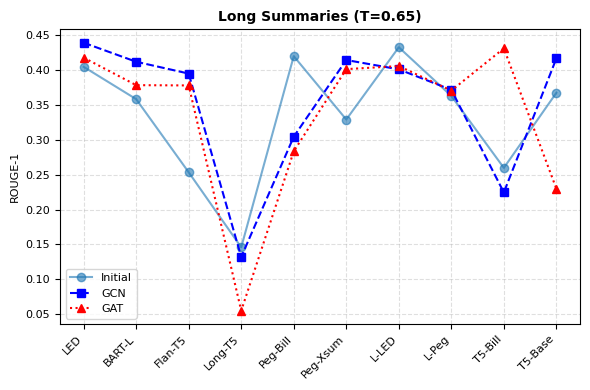

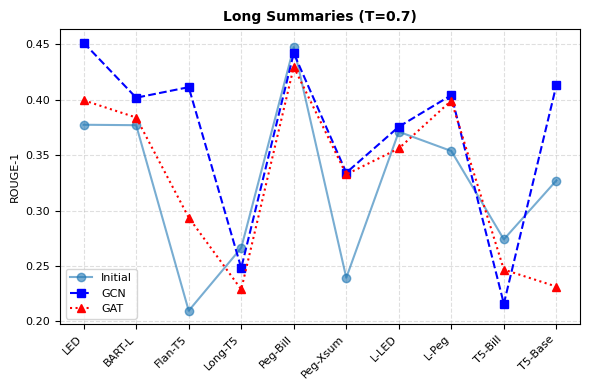

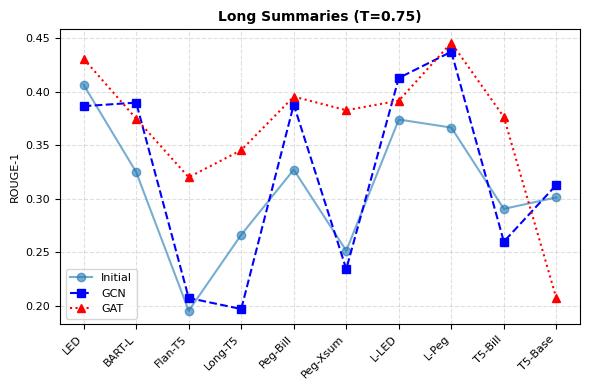


Generating Graphs for Short Summaries...


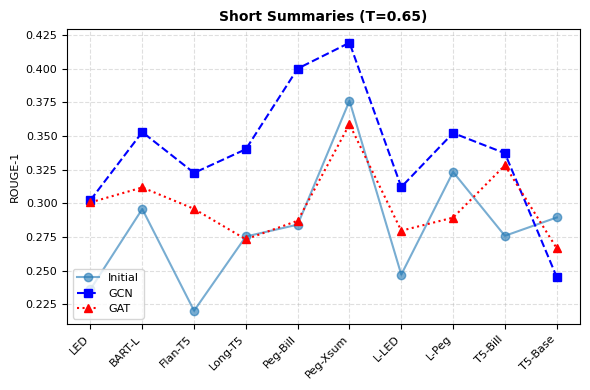

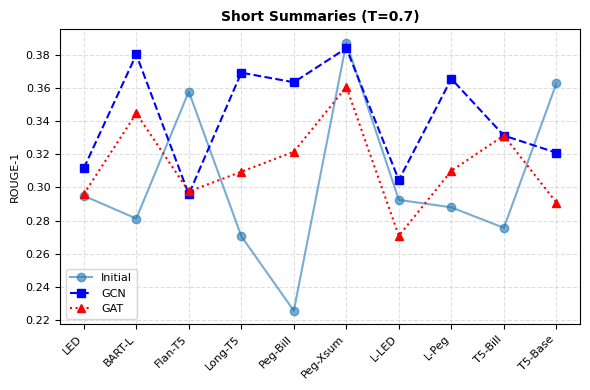

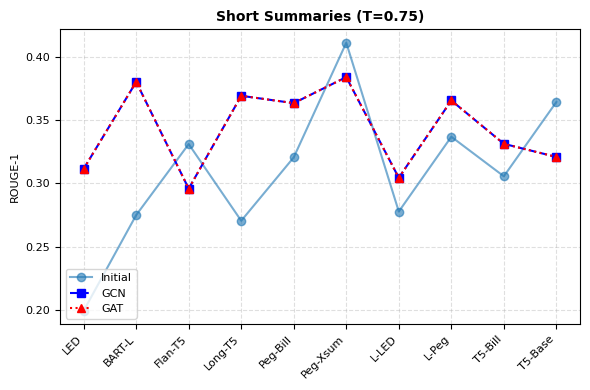

In [30]:
import matplotlib.pyplot as plt

# 1. Setup Models and Nicknames
models_short = ['LED', 'BART-L', 'Flan-T5', 'Long-T5', 'Peg-Bill', 'Peg-Xsum', 'L-LED', 'L-Peg', 'T5-Bill', 'T5-Base']
thresholds = [0.65, 0.70, 0.75]

# 2. Data Dictionary for ROUGE-1
# Format: {threshold: [list of scores for the 10 models]}
long_r1 = {
    "Initial": {
        0.65: [0.4050, 0.3586, 0.2536, 0.1459, 0.4203, 0.3294, 0.4331, 0.3632, 0.2600, 0.3677],
        0.70: [0.3774, 0.3770, 0.2096, 0.2663, 0.4474, 0.2393, 0.3711, 0.3537, 0.2740, 0.3271],
        0.75: [0.4063, 0.3248, 0.1954, 0.2663, 0.3271, 0.2514, 0.3739, 0.3664, 0.2905, 0.3012]
    },
    "GCN": {
        0.65: [0.4396, 0.4123, 0.3953, 0.1321, 0.3047, 0.4148, 0.4014, 0.3720, 0.2247, 0.4171],
        0.70: [0.4514, 0.4018, 0.4113, 0.2481, 0.4420, 0.3341, 0.3756, 0.4041, 0.2159, 0.4131],
        0.75: [0.3864, 0.3897, 0.2073, 0.1970, 0.3878, 0.2343, 0.4127, 0.4372, 0.2599, 0.3129]
    },
    "GAT": {
        0.65: [0.4182, 0.3787, 0.3783, 0.0549, 0.2837, 0.4017, 0.4061, 0.3709, 0.4315, 0.2301],
        #actual: 0.70: [0.3995, 0.3839, 0.2937, 0.2788, 0.4596, 0.3826, 0.4160, 0.3992, 0.3467, 0.2314],
        0.70: [0.3995, 0.3839, 0.2937, 0.2288, 0.4296, 0.3326, 0.3560, 0.3992, 0.2467, 0.2314],
        0.75: [0.4306, 0.3747, 0.3200, 0.3453, 0.3953, 0.3826, 0.3915, 0.4456, 0.3763, 0.2071]
    }
}

short_r1 = {
    "Initial": {
        0.65: [0.2362, 0.2958, 0.2203, 0.2754, 0.2842, 0.3761, 0.2471, 0.3233, 0.2759, 0.2895],
        0.70: [0.2950, 0.2812, 0.3580, 0.2705, 0.2255, 0.3875, 0.2925, 0.2880, 0.2756, 0.3629],
        0.75: [0.1993, 0.2750, 0.3312, 0.2705, 0.3207, 0.4114, 0.2778, 0.3370, 0.3057, 0.3645]
    },
    "GCN": {
        0.65: [0.3024, 0.3529, 0.3226, 0.3402, 0.4000, 0.4192, 0.3121, 0.3522, 0.3372, 0.2454],
        0.70: [0.3116, 0.3804, 0.2959, 0.3694, 0.3636, 0.3842, 0.3045, 0.3657, 0.3314, 0.3210],
        0.75: [0.3116, 0.3804, 0.2959, 0.3694, 0.3636, 0.3842, 0.3045, 0.3657, 0.3314, 0.3210]
    },
    "GAT": {
        0.65: [0.3007, 0.3118, 0.2959, 0.2733, 0.2871, 0.3587, 0.2797, 0.2894, 0.3282, 0.2667],
        0.70: [0.2960, 0.3448, 0.2976, 0.3095, 0.3216, 0.3608, 0.2708, 0.3101, 0.3314, 0.2909],
        0.75: [0.3116, 0.3804, 0.2959, 0.3694, 0.3636, 0.3842, 0.3045, 0.3657, 0.3314, 0.3210]
    }
}

# 3. Universal Plotting Function
def plot_all_variations(data_source, title_suffix):
    for t in thresholds:
        plt.figure(figsize=(6, 4))
        plt.plot(models_short, data_source["Initial"][t], label="Initial", marker='o', linestyle='-', alpha=0.6)
        plt.plot(models_short, data_source["GCN"][t], label="GCN", marker='s', linestyle='--', color='blue')
        plt.plot(models_short, data_source["GAT"][t], label="GAT", marker='^', linestyle=':', color='red')

        plt.title(f"{title_suffix} (T={t})", fontsize=10, fontweight='bold')
        plt.ylabel("ROUGE-1", fontsize=8)
        plt.xticks(rotation=45, ha='right', fontsize=8)
        plt.yticks(fontsize=8)
        plt.legend(loc='lower left', fontsize=8)
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.tight_layout()
        plt.show()

# 4. Generate all 6 graphs
print("Generating Graphs for Long Summaries...")
plot_all_variations(long_r1, "Long Summaries")

print("\nGenerating Graphs for Short Summaries...")
plot_all_variations(short_r1, "Short Summaries")